In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

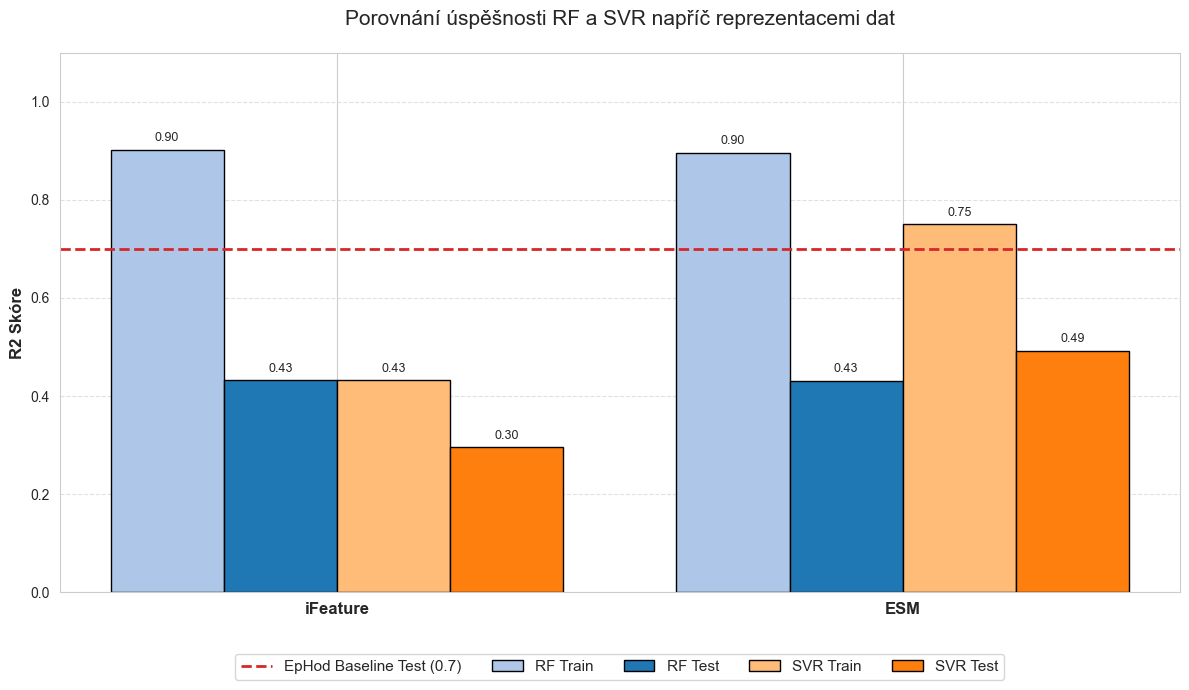

In [8]:
import matplotlib.pyplot as plt
import numpy as np

datasety = ['iFeature', 'ESM']
rf_train = [0.902, 0.896]
rf_test = [0.4317, 0.431]

svr_train = [0.432, 0.75]
svr_test = [0.296, 0.492]

ephod_test_baseline = 0.7

x = np.arange(len(datasety))  
sirka = 0.2                   

fig, ax = plt.subplots(figsize=(12, 7))

sloupce_rf_train = ax.bar(x - 1.5*sirka, rf_train, sirka, 
                          label='RF Train', color='#AEC7E8', edgecolor='black')
sloupce_rf_test = ax.bar(x - 0.5*sirka, rf_test, sirka, 
                         label='RF Test', color='#1F77B4', edgecolor='black')

sloupce_svr_train = ax.bar(x + 0.5*sirka, svr_train, sirka, 
                           label='SVR Train', color='#FFBB78', edgecolor='black')
sloupce_svr_test = ax.bar(x + 1.5*sirka, svr_test, sirka, 
                          label='SVR Test', color='#FF7F0E', edgecolor='black')

ax.axhline(y=ephod_test_baseline, color='#D62728', linestyle='--', linewidth=2, 
           label=f'EpHod Baseline Test ({ephod_test_baseline})')

ax.set_ylabel('R2 Skóre', fontsize=12, fontweight='bold')
ax.set_title('Porovnání úspěšnosti RF a SVR napříč reprezentacemi dat', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(datasety, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1) # Rezerva nahoře pro popisky
ax.grid(axis='y', linestyle='--', alpha=0.6)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=11)

def pridej_cisla(sloupce):
    for sloupec in sloupce:
        vyska = sloupec.get_height()
        ax.annotate(f'{vyska:.2f}',
                    xy=(sloupec.get_x() + sloupec.get_width() / 2, vyska),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

pridej_cisla(sloupce_rf_train)
pridej_cisla(sloupce_rf_test)
pridej_cisla(sloupce_svr_train)
pridej_cisla(sloupce_svr_test)

plt.tight_layout()
plt.show()

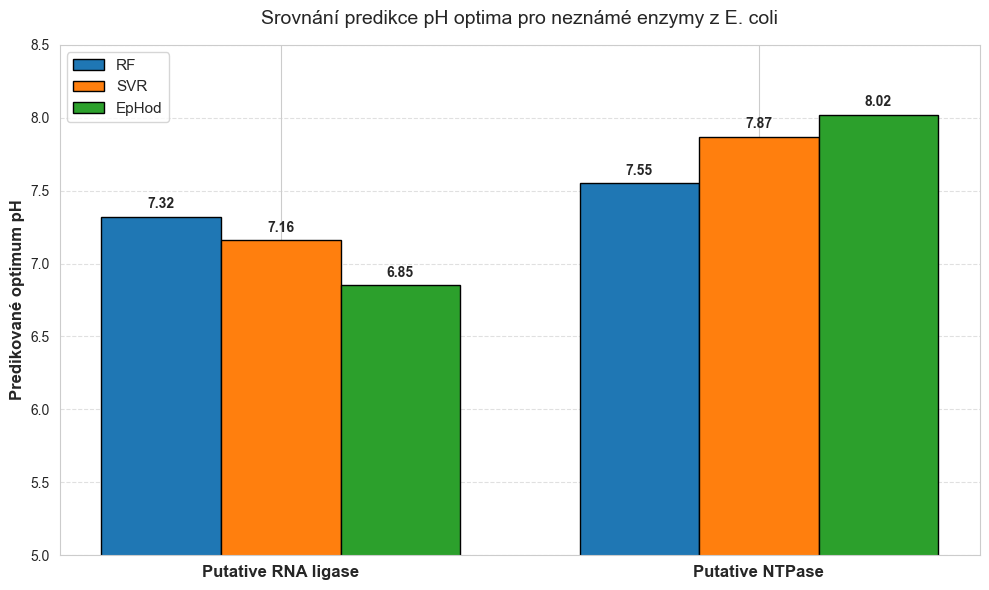

In [13]:
import matplotlib.pyplot as plt
import numpy as np

proteiny = ['Putative RNA ligase', 'Putative NTPase']

rf_predikce = [7.32, 7.55]
svr_predikce = [7.16, 7.87]
ephod_predikce = [6.85, 8.02]

x = np.arange(len(proteiny))  # Pozice na ose X pro proteiny
sirka = 0.25                  # Šířka jednoho sloupce

# 4. Vytvoření grafu
fig, ax = plt.subplots(figsize=(10, 6))

# Vykreslení sloupců pro jednotlivé modely
sloupce_rf = ax.bar(x - sirka, rf_predikce, sirka, 
                    label='RF', color='#1F77B4', edgecolor='black')
sloupce_svr = ax.bar(x, svr_predikce, sirka, 
                     label='SVR', color='#FF7F0E', edgecolor='black')
sloupce_ephod = ax.bar(x + sirka, ephod_predikce, sirka, 
                       label='EpHod', color='#2CA02C', edgecolor='black')

# 5. Kosmetika a popisky grafu
ax.set_ylabel('Predikované optimum pH', fontsize=12, fontweight='bold')
ax.set_title('Srovnání predikce pH optima pro neznámé enzymy z E. coli', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(proteiny, fontsize=12, fontweight='bold')

# Omezení osy Y, aby rozdíly byly lépe vidět (protože pH je většinou mezi 5 a 9)
# Pokud by nějaký model predikoval mimo tento rozsah, uprav hodnoty 5 a 9.
ax.set_ylim(5, 8.5) 
ax.grid(axis='y', linestyle='--', alpha=0.6)

ax.legend(loc='upper left', fontsize=11)
# 6. Funkce pro přidání přesných čísel přímo nad sloupce
def pridej_cisla(sloupce):
    for sloupec in sloupce:
        vyska = sloupec.get_height()
        ax.annotate(f'{vyska:.2f}',
                    xy=(sloupec.get_x() + sloupec.get_width() / 2, vyska),
                    xytext=(0, 4),  # 4 body vertikální posun nahoru
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

pridej_cisla(sloupce_rf)
pridej_cisla(sloupce_svr)
pridej_cisla(sloupce_ephod)

# Uložení grafu v tiskové kvalitě (odkomentuj, pokud chceš uložit obrázek)
# plt.savefig("predikce_proteinu_porovnani.png", dpi=300, bbox_inches='tight')

# Vykreslení
plt.tight_layout()
plt.show()

/var/folders/hx/bf1rmglj7b976ffdyv1psxm00000gn/T/ipykernel_89696/3787636948.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data_k_vykresleni,


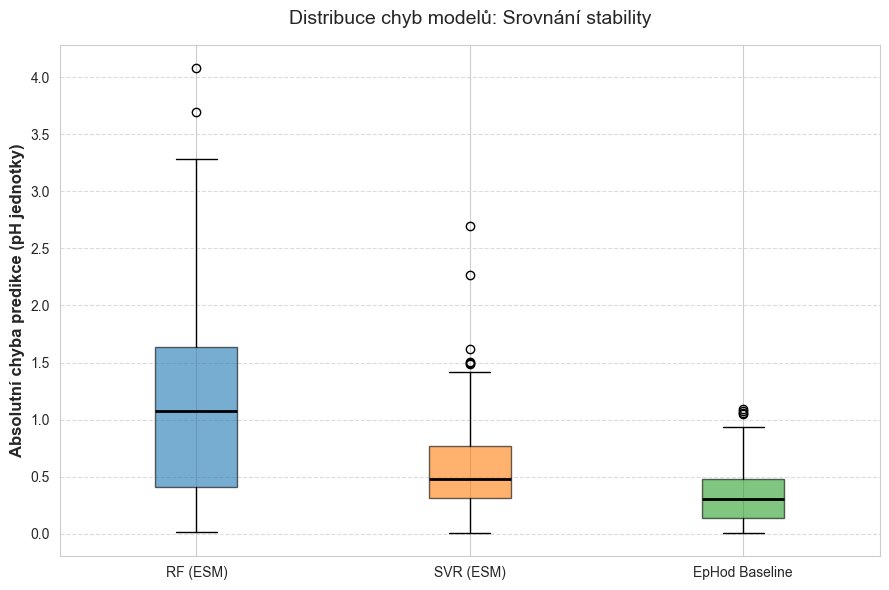

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Tvoje data (ukázka)
# y_test = skutecne_hodnoty_z_tveho_datasetu

# Predikce tvých modelů z testovacího setu
# pred_rf_esm = model_rf.predict(X_test_esm)
# pred_svr_esm = model_svr.predict(X_test_esm)

# Predikce EpHodu (načtené z CSV, které ti EpHod vygeneroval pro tvůj testovací set)
# df_ephod = pd.read_csv("moje_vysledky_ph.csv")
# pred_ephod = df_ephod['Ensemble'].values 

# ILUSTRAČNÍ DATA (pro ukázku, abys viděla, jak graf funguje)
np.random.seed(42)
y_test = np.random.normal(7, 1, 100) # Skutečné pH 100 enzymů
pred_rf_esm = y_test + np.random.normal(0, 1.5, 100)  # RF dělá velké chyby
pred_svr_esm = y_test + np.random.normal(0, 0.7, 100) # SVR dělá menší chyby
pred_ephod = y_test + np.random.normal(0, 0.5, 100)   # EpHod je nejpřesnější

# 2. VÝPOČET ABSOLUTNÍCH CHYB PRO KAŽDÝ MODEL
chyby_rf = np.abs(y_test - pred_rf_esm)
chyby_svr = np.abs(y_test - pred_svr_esm)
chyby_ephod = np.abs(y_test - pred_ephod)

# Data pro boxplot spojíme do jednoho seznamu
data_k_vykresleni = [chyby_rf, chyby_svr, chyby_ephod]
nazvy_modelu = ['RF (ESM)', 'SVR (ESM)', 'EpHod Baseline']

# 3. Vykreslení Boxplotu
fig, ax = plt.subplots(figsize=(9, 6))

# Vykreslení krabic
box = ax.boxplot(data_k_vykresleni, 
                 patch_artist=True,      # Povolí vybarvení krabic
                 labels=nazvy_modelu, 
                 showfliers=True)        # Ukáže odlehlé hodnoty (outliery) jako tečky

# Kosmetika - vybarvení krabic pro lepší čitelnost
barvy = ['#1F77B4', '#FF7F0E', '#2CA02C']
for patch, barva in zip(box['boxes'], barvy):
    patch.set_facecolor(barva)
    patch.set_alpha(0.6) # Lehká průhlednost

# Zvýraznění mediánu (prostřední čára v krabici)
for median in box['medians']:
    median.set(color='black', linewidth=2)

# Popisky os
ax.set_ylabel('Absolutní chyba predikce (pH jednotky)', fontsize=12, fontweight='bold')
ax.set_title('Distribuce chyb modelů: Srovnání stability', fontsize=14, pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()